# 05 Outlier Handling

วิเคราะห์และกำจัด outlier สำหรับ `total_time_min` และ phase time แต่ละขั้นตอน

**โครงสร้าง**
1. Load data
2. Phase share & modified Z-score per phase → flag fast/slow
3. **Total time outlier แยกตาม Place × CarNo** ← ส่วนหลัก
4. Remove outliers & save


In [64]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

## Load Featured Data

In [65]:
source_path = '../../data/interim/vw_timestamp_dashboard_featured.csv'
df_feature = pd.read_csv(source_path)

phase_cols = [
    'wait_call_min',
    'prepare_loading_min',
    'loading_time_min',
    'close_job_min',
]
total_col = 'total_time_min'

required_cols = phase_cols + [total_col]
missing_cols = [c for c in required_cols if c not in df_feature.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

print(f'Source: {source_path}')
print(f'Shape : {df_feature.shape}')
df_feature[required_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T

Source: ../../data/interim/vw_timestamp_dashboard_featured.csv
Shape : (26538, 68)


,count,mean,std,min,50%,75%,90%,95%,99%,max
wait_call_min,26538.0,8.966749,8.945439,0.05,6.03,11.62,19.806,26.7000,43.9763,88.73
prepare_loading_min,26538.0,8.937825,10.327419,0.10,5.38,12.18,21.906,29.3215,46.4200,301.08
loading_time_min,26538.0,25.150954,19.229502,0.02,20.80,34.50,51.730,64.2030,86.8615,213.98
close_job_min,26538.0,16.776846,13.448396,1.13,13.45,21.37,31.880,39.9500,58.7552,339.90
total_time_min,26538.0,59.832307,25.278969,5.43,56.42,75.60,94.380,104.1745,117.5019,385.07


## Build Phase Share of Total

In [66]:
analysis_df = df_feature.copy()

valid_total = analysis_df[total_col].where(analysis_df[total_col] > 0)
for col in phase_cols:
    analysis_df[f'{col}_share'] = analysis_df[col] / valid_total

share_cols = [f'{c}_share' for c in phase_cols]
share_summary = analysis_df[share_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T
share_summary

,count,mean,std,min,50%,75%,90%,95%,99%,max
wait_call_min_share,26538.0,0.160006,0.136896,0.000575,0.116332,0.225089,0.356801,0.446548,0.605758,0.932226
prepare_loading_min_share,26538.0,0.151727,0.147116,0.000360,0.101701,0.224246,0.366393,0.459718,0.618365,0.913526
loading_time_min_share,26538.0,0.395119,0.205229,0.000547,0.384532,0.543829,0.682321,0.752770,0.846112,0.950777
close_job_min_share,26538.0,0.293149,0.163869,0.013664,0.268447,0.397584,0.524621,0.598465,0.735577,0.975027


## Detect Fast/Slow Outliers Per Phase

In [67]:
DECODE_CARTYPE = {0: '10-Wheel', 1: '4-Wheel', 2: '6-Wheel', 3: 'Trailer'}

def map_cartype(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return series.map(DECODE_CARTYPE).fillna(series.astype(str))
    return series.astype(str)

def modified_zscore(series: pd.Series) -> pd.Series:
    median = series.median()
    mad = (series - median).abs().median()
    if pd.isna(mad) or mad == 0:
        return pd.Series(np.nan, index=series.index)
    return 0.6745 * (series - median) / mad

if 'CarType' in analysis_df.columns:
    analysis_df['CarTypeLabel'] = map_cartype(analysis_df['CarType'])
    group_key = 'CarTypeLabel'
else:
    analysis_df['CarTypeLabel'] = 'Unknown'
    group_key = None

for col in phase_cols:
    share_col = f'{col}_share'
    z_col = f'{col}_share_mz'
    flag_col = f'{col}_speed_flag'

    if group_key is None:
        analysis_df[z_col] = modified_zscore(analysis_df[share_col])
    else:
        analysis_df[z_col] = analysis_df.groupby(group_key, dropna=False)[share_col].transform(modified_zscore)

    analysis_df[flag_col] = np.select(
        [analysis_df[z_col] >= 3.5, analysis_df[z_col] <= -3.5],
        ['slow_abnormal', 'fast_abnormal'],
        default='normal',
    )

summary_rows = []
for col in phase_cols:
    flag_col = f'{col}_speed_flag'
    counts = analysis_df[flag_col].value_counts()
    total_n = int(counts.sum())
    for flag in ['slow_abnormal', 'fast_abnormal', 'normal']:
        n = int(counts.get(flag, 0))
        summary_rows.append({
            'phase': col,
            'flag': flag,
            'count': n,
            'pct': (n / total_n * 100) if total_n else 0,
        })

outlier_summary = pd.DataFrame(summary_rows)
outlier_summary

,phase,flag,count,pct
0,wait_call_min,slow_abnormal,998,3.760645
1,wait_call_min,fast_abnormal,0,0.000000
2,wait_call_min,normal,25540,96.239355
3,prepare_loading_min,slow_abnormal,905,3.410204
4,prepare_loading_min,fast_abnormal,0,0.000000
5,prepare_loading_min,normal,25633,96.589796
6,loading_time_min,slow_abnormal,0,0.000000
7,loading_time_min,fast_abnormal,0,0.000000
8,loading_time_min,normal,26538,100.000000
9,close_job_min,slow_abnormal,64,0.241164


## Outlier Summary and Top Trucks

In [68]:
pivot_summary = outlier_summary.pivot(index='phase', columns='flag', values='pct').fillna(0).round(2)
print('Percent of rows by phase and speed flag (%)')
display(pivot_summary)

base_id_cols = [
    'PackListNo',
    'CarNo',
    'CarTypeLabel',
    'PickListType',
    'PlantName',
    'PostLocationName',
    'OperatorCarConfirm',
    'CarConfirm',
    'FirstPostPallet',
    'LastPostPallet',
    'PostingTime',
]
id_cols = [c for c in base_id_cols if c in analysis_df.columns]

for col in phase_cols:
    share_col = f'{col}_share'
    z_col = f'{col}_share_mz'
    flag_col = f'{col}_speed_flag'

    print(f'\n=== {col} : SLOW ABNORMAL (top 10) ===')
    slow_df = analysis_df[analysis_df[flag_col] == 'slow_abnormal']
    if slow_df.empty:
        print('No slow abnormal rows')
    else:
        display_cols = id_cols + [col, total_col, share_col, z_col]
        display(slow_df.sort_values(z_col, ascending=False)[display_cols].head(10))

    print(f'\n=== {col} : FAST ABNORMAL (top 10) ===')
    fast_df = analysis_df[analysis_df[flag_col] == 'fast_abnormal']
    if fast_df.empty:
        print('No fast abnormal rows')
    else:
        display_cols = id_cols + [col, total_col, share_col, z_col]
        display(fast_df.sort_values(z_col, ascending=True)[display_cols].head(10))

if 'CarNo' in analysis_df.columns:
    print('\nTop trucks with repeated abnormal behavior (all phases combined)')
    long_rows = []
    for col in phase_cols:
        flag_col = f'{col}_speed_flag'
        tmp = analysis_df.loc[analysis_df[flag_col] != 'normal', ['CarNo', flag_col]].copy()
        tmp = tmp.rename(columns={flag_col: 'flag'})
        tmp['phase'] = col
        long_rows.append(tmp)

    long_df = pd.concat(long_rows, ignore_index=True) if long_rows else pd.DataFrame(columns=['CarNo', 'flag', 'phase'])
    if long_df.empty:
        print('No abnormal rows found for CarNo')
    else:
        truck_summary = (
            long_df.groupby(['CarNo', 'flag'])
            .size()
            .unstack(fill_value=0)
            .reset_index()
        )
        # ensure both flag columns exist even if no rows were flagged
        for _flag in ['slow_abnormal', 'fast_abnormal']:
            if _flag not in truck_summary.columns:
                truck_summary[_flag] = 0
        truck_summary = truck_summary.sort_values(
            ['slow_abnormal', 'fast_abnormal'], ascending=False
        )
        display(truck_summary.head(20))


Percent of rows by phase and speed flag (%)


flag,fast_abnormal,normal,slow_abnormal
phase,,,
close_job_min,0.0,99.76,0.24
loading_time_min,0.0,100.00,0.00
prepare_loading_min,0.0,96.59,3.41
wait_call_min,0.0,96.24,3.76



=== wait_call_min : SLOW ABNORMAL (top 10) ===


,PackListNo,CarNo,CarTypeLabel,PickListType,PlantName,PostLocationName,OperatorCarConfirm,CarConfirm,FirstPostPallet,LastPostPallet,PostingTime,wait_call_min,total_time_min,wait_call_min_share,wait_call_min_share_mz
6167,SB1PL250428123,71-0393 ลำพูน,Trailer,2.0,SB1,10.0,2025-05-02 09:52:30,2025-05-02 10:13:28,2025-05-02 10:13:46,2025-05-02 10:14:53,2025-05-02 10:18:11,20.97,25.68,0.816589,16.141278
342,SB1PL250110008,82-5229,Trailer,0.0,SB1,9.0,2025-01-10 07:58:20,2025-01-10 08:19:16,2025-01-10 08:19:52,2025-01-10 08:20:51,2025-01-10 08:24:43,20.93,26.38,0.793404,15.647806
26011,SB1PL260508090,90-2718,Trailer,0.0,SB1,4.0,2026-05-08 16:02:54,2026-05-08 17:19:28,2026-05-08 17:20:11,2026-05-08 17:42:13,2026-05-08 17:47:47,76.57,104.88,0.730072,14.299833
12311,SB1PL250813091,71-3545 ขอนแก่น,Trailer,2.0,SB1,7.0,2025-08-14 09:35:28,2025-08-14 10:57:53,2025-08-14 11:01:40,2025-08-14 11:27:25,2025-08-14 11:31:51,82.42,116.38,0.708197,13.834234
263,SB1PL241226040,70-3048 กุฉินารายณ์,Trailer,2.0,SB1,10.0,2025-01-08 15:52:33,2025-01-08 16:49:10,2025-01-08 16:56:10,2025-01-08 17:03:53,2025-01-08 17:13:32,56.62,80.98,0.699185,13.642413
25624,SB1PL260430120,70-4200,Trailer,1.0,SB1,7.0,2026-05-02 07:43:37,2026-05-02 09:04:37,2026-05-02 09:07:24,2026-05-02 09:33:13,2026-05-02 09:41:40,81.00,118.05,0.686150,13.364970
264,SB1PL241226042,70-3048 ยโสธร,Trailer,2.0,SB1,10.0,2025-01-08 15:53:03,2025-01-08 16:48:52,2025-01-08 17:06:26,2025-01-08 17:08:24,2025-01-08 17:15:21,55.82,82.30,0.678250,13.196831
265,SB1PL241226044,70-3048 สุโขทัย,Trailer,2.0,SB1,10.0,2025-01-08 15:53:51,2025-01-08 16:48:37,2025-01-08 17:04:34,2025-01-08 17:05:15,2025-01-08 17:15:41,54.77,81.83,0.669314,13.006637
25723,SB1PL260502074,70-8081 ชลบุรี,Trailer,2.0,SB1,6.0,2026-05-04 13:15:28,2026-05-04 14:16:14,2026-05-04 14:19:35,2026-05-04 14:38:11,2026-05-04 14:46:51,60.77,91.38,0.665025,12.915343
24901,SB1PL260420046,80-8375แทน80-7406,Trailer,1.0,SB1,10.0,2026-04-22 07:39:24,2026-04-22 08:45:59,2026-04-22 08:50:39,2026-04-22 09:15:12,2026-04-22 09:20:17,66.58,100.88,0.659992,12.808216



=== wait_call_min : FAST ABNORMAL (top 10) ===
No fast abnormal rows

=== prepare_loading_min : SLOW ABNORMAL (top 10) ===


,PackListNo,CarNo,CarTypeLabel,PickListType,PlantName,PostLocationName,OperatorCarConfirm,CarConfirm,FirstPostPallet,LastPostPallet,PostingTime,prepare_loading_min,total_time_min,prepare_loading_min_share,prepare_loading_min_share_mz
24038,SB1PL260402114,67-6310 ทุ่งสง,Trailer,2.0,SB1,11.0,2026-04-03 07:44:51,2026-04-03 07:48:42,2026-04-03 12:49:47,2026-04-03 13:04:41,2026-04-03 13:14:26,301.08,329.58,0.913526,12.982368
4202,SB1PL250324093,70-6732 ส่งลาว,Trailer,2.0,SB1,11.0,2025-03-26 07:32:04,2025-03-26 07:33:11,2025-03-26 08:14:28,2025-03-26 08:15:07,2025-03-26 08:18:48,41.28,46.73,0.883373,12.522865
5334,SB1PL250419012,68-3480,Trailer,2.0,SB1,9.0,2025-04-19 09:03:48,2025-04-19 09:06:34,2025-04-19 10:14:57,2025-04-19 10:15:52,2025-04-19 10:21:59,68.38,78.18,0.874648,12.389918
21659,SB1PL260219102,70-4809 ลาว24/02,Trailer,2.0,SB1,10.0,2026-02-24 07:32:24,2026-02-24 07:35:06,2026-02-24 09:08:08,2026-02-24 09:18:31,2026-02-24 09:20:13,93.03,107.82,0.862827,12.209777
15105,SB1PL251002072,81-8139,Trailer,2.0,SB1,4.0,2025-10-03 07:43:54,2025-10-03 07:47:19,2025-10-03 09:00:35,2025-10-03 09:06:42,2025-10-03 09:13:18,73.27,89.40,0.819575,11.550675
16662,SB1PL251030070,73-1499ดูโฮม,Trailer,2.0,SB1,9.0,2025-10-31 14:44:12,2025-10-31 14:52:46,2025-10-31 16:28:07,2025-10-31 16:30:34,2025-10-31 16:42:24,95.35,118.20,0.806684,11.354228
4581,SB1PL250402006,82-2068 เปลี่ยนแพ็คไซด์,Trailer,0.0,SB1,4.0,2025-04-02 08:04:48,2025-04-02 08:10:39,2025-04-02 09:40:30,2025-04-02 09:53:33,2025-04-02 09:56:46,89.85,111.97,0.802447,11.289669
16663,SB1PL251030072,73-1499ดูโฮม,Trailer,2.0,SB1,10.0,2025-10-31 14:44:41,2025-10-31 14:52:58,2025-10-31 16:28:41,2025-10-31 16:30:08,2025-10-31 16:44:23,95.72,119.70,0.799666,11.247287
19528,SB1PL260115063,82-2068,Trailer,2.0,SB1,10.0,2026-01-16 11:27:43,2026-01-16 11:31:00,2026-01-16 13:06:52,2026-01-16 13:21:26,2026-01-16 13:29:31,95.87,121.80,0.787110,11.055953
13639,SB1PL250905060,70-4129 เพิ่ม,Trailer,2.0,SB1,8.0,2025-09-05 17:18:40,2025-09-05 17:22:49,2025-09-05 18:16:59,2025-09-05 18:17:36,2025-09-05 18:27:32,54.17,68.87,0.786554,11.047486



=== prepare_loading_min : FAST ABNORMAL (top 10) ===
No fast abnormal rows

=== loading_time_min : SLOW ABNORMAL (top 10) ===
No slow abnormal rows

=== loading_time_min : FAST ABNORMAL (top 10) ===
No fast abnormal rows

=== close_job_min : SLOW ABNORMAL (top 10) ===


,PackListNo,CarNo,CarTypeLabel,PickListType,PlantName,PostLocationName,OperatorCarConfirm,CarConfirm,FirstPostPallet,LastPostPallet,PostingTime,close_job_min,total_time_min,close_job_min_share,close_job_min_share_mz
11850,SB1PL250805089,71-1808 ลำพูน,4-Wheel,2.0,SB1,11.0,2025-08-06 09:46:35,2025-08-06 09:47:57,2025-08-06 09:48:14,2025-08-06 09:48:26,2025-08-06 11:00:40,72.23,74.08,0.975027,4.775192
3959,SB1PL250321035,71-3217,6-Wheel,2.0,SB1,3.0,2025-03-21 13:37:38,2025-03-21 13:38:51,2025-03-21 13:41:24,2025-03-21 13:42:34,2025-03-21 14:22:28,39.90,44.83,0.890029,4.481296
19348,SB1PL260113005,71-0542,4-Wheel,0.0,SB1,10.0,2026-01-13 07:40:30,2026-01-13 07:53:51,2026-01-13 08:03:09,2026-01-13 08:11:25,2026-01-13 13:47:38,336.22,367.13,0.915806,4.383285
19362,SB1PL260113025,83-4505,6-Wheel,0.0,SB1,8.0,2026-01-13 10:30:39,2026-01-13 10:35:56,2026-01-13 10:48:10,2026-01-13 10:57:26,2026-01-13 13:57:44,180.30,207.08,0.870678,4.349720
19353,SB1PL260113012,70-4789,4-Wheel,0.0,SB1,6.0,2026-01-13 08:41:32,2026-01-13 08:48:07,2026-01-13 08:49:07,2026-01-13 09:11:58,2026-01-13 13:49:59,278.02,308.45,0.901345,4.287586
12269,SB1PL250812037,71-2781 ขอนแก่น,4-Wheel,2.0,SB1,10.0,2025-08-13 15:40:24,2025-08-13 15:41:27,2025-08-13 15:47:28,2025-08-13 15:49:47,2025-08-13 17:15:07,85.33,94.72,0.900866,4.284412
19345,SB1PL260112075,89-1395แทน89-4045,4-Wheel,2.0,SB1,3.0,2026-01-13 07:17:57,2026-01-13 07:44:34,2026-01-13 07:52:05,2026-01-13 07:56:08,2026-01-13 13:36:02,339.90,378.08,0.899016,4.272171
11291,SB1PL250726040,70-3963,4-Wheel,0.0,SB1,9.0,2025-07-26 13:05:46,2025-07-26 13:07:05,2025-07-26 13:07:22,2025-07-26 13:08:48,2025-07-26 13:33:42,24.90,27.93,0.891515,4.222528
19364,SB1PL260113029,71-9972,4-Wheel,0.0,SB1,10.0,2026-01-13 10:52:43,2026-01-13 11:00:09,2026-01-13 11:05:23,2026-01-13 11:13:09,2026-01-13 13:59:57,166.80,187.23,0.890883,4.218348
26320,SB1PL260513052,72-9903,4-Wheel,0.0,SB1,10.0,2026-05-13 15:53:36,2026-05-13 15:54:56,2026-05-13 15:56:07,2026-05-13 15:58:57,2026-05-13 16:39:26,40.48,45.83,0.883264,4.167930



=== close_job_min : FAST ABNORMAL (top 10) ===
No fast abnormal rows

Top trucks with repeated abnormal behavior (all phases combined)


flag,CarNo,slow_abnormal,fast_abnormal
1068,82-5866,20,0
742,71-2054,16,0
1047,82-0969,13,0
1016,81-6503,12,0
1023,81-7485,12,0
1036,81-8178,12,0
914,72-5907,11,0
760,71-2667,10,0
46,60-2983,9,0
412,70-4568,9,0


## วิเคราะห์ Outlier Total Time แยกตาม Place × CarNo

วิเคราะห์ว่ารถคันไหนใน Place ไหน **เร็วหรือช้าผิดปกติ** เมื่อเทียบกับรถคันอื่นใน Place เดียวกัน

| level | วิธี | flag |
|-------|------|------|
| **Trip** | modified Z-score ของ `total_time_min` ภายใน place | `slow_abnormal` / `fast_abnormal` / `normal` |
| **Truck** | modified Z-score ของ **median** `total_time_min` ต่อ CarNo ภายใน place | `slow_abnormal` / `fast_abnormal` / `normal` |


Place column : PostLocationName
Places (10) : [np.float64(1.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0)]

=== Trip Outliers per Place ===


,PostLocationName,normal,slow_abnormal,fast_abnormal,total_trips,slow_%,fast_%
8,10.0,6325,30,0,6355,0.47,0.0
1,3.0,4606,12,0,4618,0.26,0.0
5,7.0,3337,7,0,3344,0.21,0.0
6,8.0,3269,6,0,3275,0.18,0.0
7,9.0,3785,4,0,3789,0.11,0.0
4,6.0,2397,4,0,2401,0.17,0.0
3,5.0,528,2,0,530,0.38,0.0
9,11.0,167,1,0,168,0.60,0.0
0,1.0,76,0,0,76,0.00,0.0
2,4.0,1982,0,0,1982,0.00,0.0



=== รถที่มี Total Time ผิดปกติ แยกตาม Place (|mz| >= 3.0) ===


,PostLocationName,CarNo,trips,median_min,mean_min,std_min,truck_mz,truck_flag
0,3.0,89-1395แทน89-4045,1,378.08,378.08,NaN,13.99,slow_abnormal
1,3.0,89-4045แทน89-1395,2,204.94,204.94,206.43,6.31,slow_abnormal
2,3.0,61-2746ทุ่งสง,1,175.57,175.57,NaN,5.01,slow_abnormal
3,3.0,71-0922 ลำพูน,1,155.17,155.17,NaN,4.10,slow_abnormal
4,3.0,70-6368แทน70-6370,1,147.48,147.48,NaN,3.76,slow_abnormal
5,3.0,70-1635ลาว,1,132.43,132.43,NaN,3.09,slow_abnormal
6,3.0,70-3744,1,131.95,131.95,NaN,3.07,slow_abnormal
7,5.0,60-2172 ทุ่งสง,1,138.97,138.97,NaN,3.86,slow_abnormal
8,5.0,70-2301,1,121.70,121.70,NaN,3.13,slow_abnormal
9,5.0,70-3369 ส่งออกลาว,1,121.27,121.27,NaN,3.11,slow_abnormal


c:\SCG-Roofing\WMS-ML\WMS-ML\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) Arial.
  fig.canvas.draw()
c:\SCG-Roofing\WMS-ML\WMS-ML\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) Arial.
  fig.canvas.draw()
c:\SCG-Roofing\WMS-ML\WMS-ML\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) Arial.
  fig.canvas.draw()
c:\SCG-Roofing\WMS-ML\WMS-ML\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) Arial.
  fig.canvas.draw()
c:\SCG-Roofing\WMS-ML\WMS-ML\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) Arial.
  fig.canvas.draw()
c:\SCG-Roofing\WMS-ML\WMS-ML\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) miss

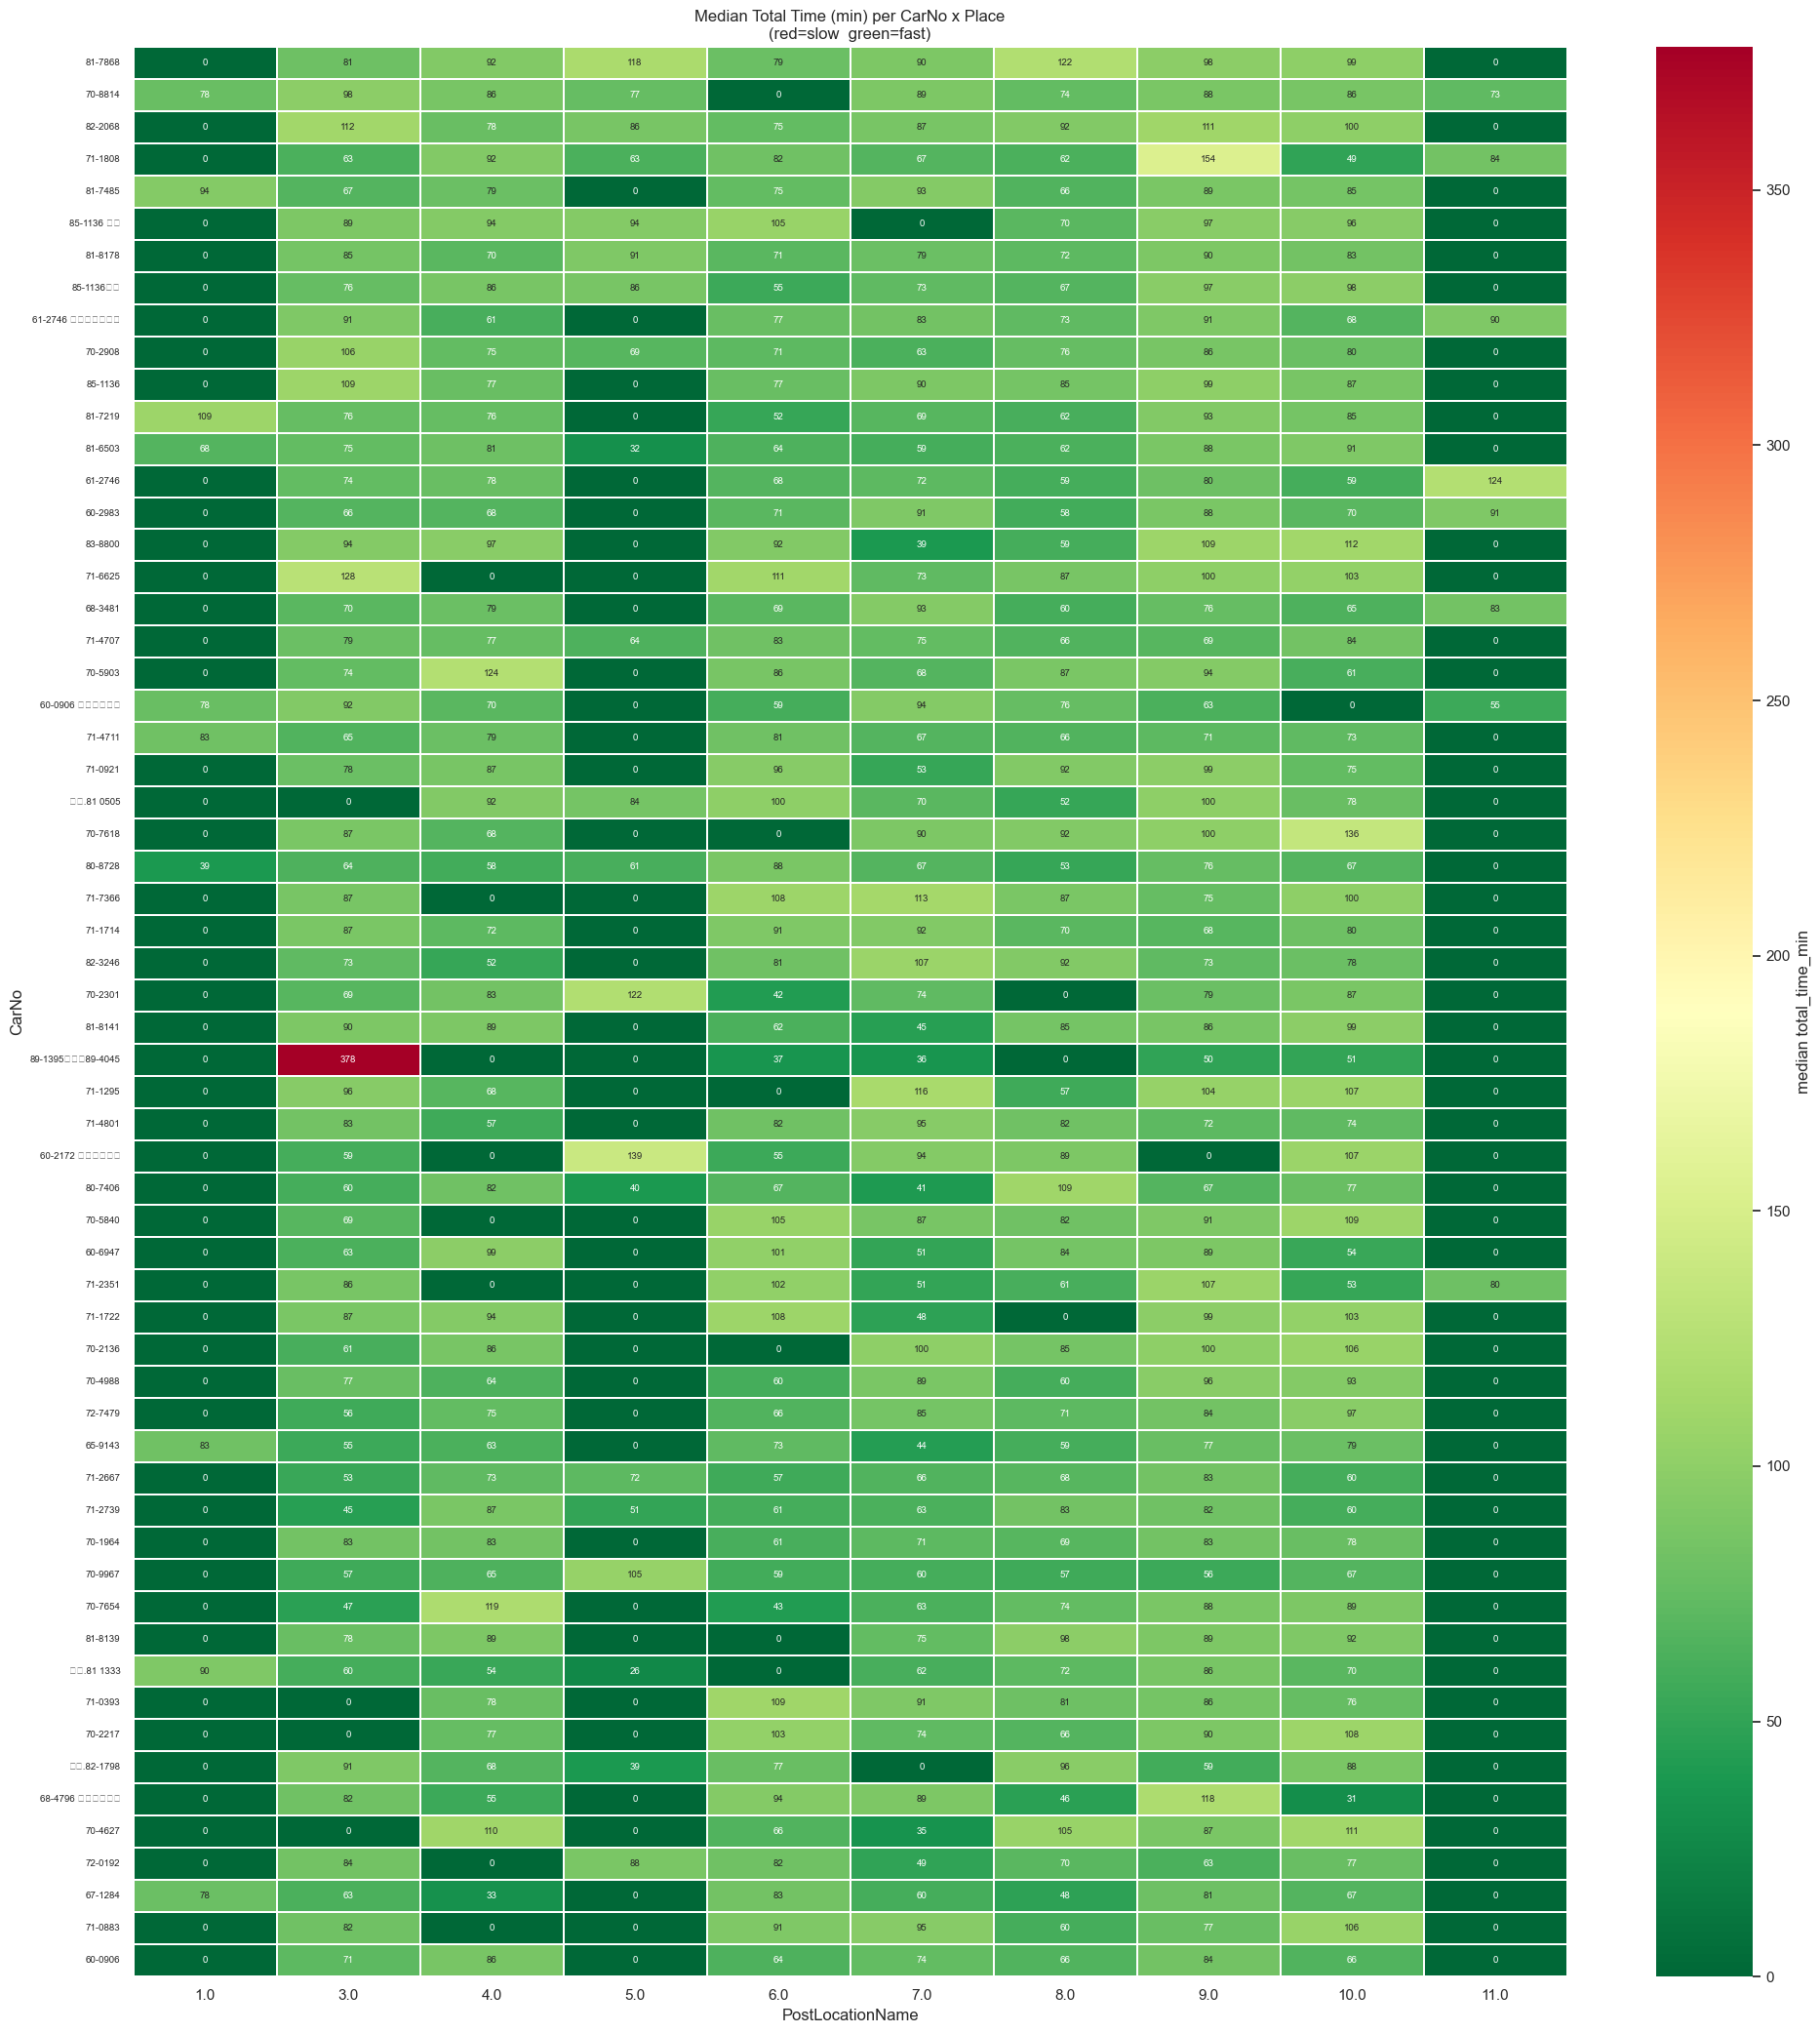

In [69]:
place_col = next((c for c in ['PostLocationName', 'PlantName'] if c in analysis_df.columns), None)
MZ_TRIP  = 3.5   # threshold ระดับ trip (ภายใน place)
MZ_TRUCK = 3.0   # threshold ระดับ CarNo (median vs. peers ใน place เดียวกัน)

if place_col is None:
    print('ไม่พบคอลัมน์ place (PostLocationName / PlantName)')
else:
    places = sorted(analysis_df[place_col].dropna().unique())
    print(f'Place column : {place_col}')
    print(f'Places ({len(places)}) : {places}')

    # ── Trip-level: flag total_time_min ภายในแต่ละ place ────────────────
    analysis_df['total_place_mz'] = (
        analysis_df.groupby(place_col, dropna=False)[total_col]
        .transform(modified_zscore)
    )
    analysis_df['total_place_flag'] = np.select(
        [analysis_df['total_place_mz'] >= MZ_TRIP,
         analysis_df['total_place_mz'] <= -MZ_TRIP],
        ['slow_abnormal', 'fast_abnormal'],
        default='normal',
    )

    # ── Summary ระดับ Place ───────────────────────────────────────────────
    place_summary = (
        analysis_df.groupby([place_col, 'total_place_flag'])
        .size()
        .unstack(fill_value=0)
        .rename_axis(None, axis=1)
        .reset_index()
    )
    for _c in ['slow_abnormal', 'fast_abnormal', 'normal']:
        if _c not in place_summary.columns:
            place_summary[_c] = 0
    _tot = place_summary[['slow_abnormal', 'fast_abnormal', 'normal']].sum(axis=1)
    place_summary['total_trips'] = _tot
    place_summary['slow_%']      = (place_summary['slow_abnormal'] / _tot * 100).round(2)
    place_summary['fast_%']      = (place_summary['fast_abnormal'] / _tot * 100).round(2)
    print('\n=== Trip Outliers per Place ===')
    display(place_summary.sort_values('slow_abnormal', ascending=False))

    # ── Truck-level: median total_time ของแต่ละ CarNo ต่อ Place ─────────
    if 'CarNo' in analysis_df.columns:
        truck_stats = (
            analysis_df.groupby([place_col, 'CarNo'], dropna=False)[total_col]
            .agg(trips='count', median_min='median', mean_min='mean', std_min='std')
            .reset_index()
        )
        truck_stats['truck_mz'] = (
            truck_stats.groupby(place_col)['median_min']
            .transform(modified_zscore)
        )
        truck_stats['truck_flag'] = np.select(
            [truck_stats['truck_mz'] >= MZ_TRUCK,
             truck_stats['truck_mz'] <= -MZ_TRUCK],
            ['slow_abnormal', 'fast_abnormal'],
            default='normal',
        )
        truck_flag_map = truck_stats.set_index([place_col, 'CarNo'])['truck_flag'].to_dict()

        abnormal_trucks = (
            truck_stats[truck_stats['truck_flag'] != 'normal']
            .sort_values([place_col, 'truck_mz'], ascending=[True, False])
            .round(2)
        )
        print(f'\n=== รถที่มี Total Time ผิดปกติ แยกตาม Place (|mz| >= {MZ_TRUCK}) ===')
        if abnormal_trucks.empty:
            print('ไม่พบรถที่ผิดปกติในระดับ threshold นี้')
        else:
            display(abnormal_trucks.reset_index(drop=True))

        # ── Heatmap: median total_time ของทุก CarNo x Place ──────────────
        pivot = truck_stats.pivot(index='CarNo', columns=place_col, values='median_min')
        pivot = pivot.dropna(how='all')
        if pivot.shape[0] > 60:
            pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).head(60).index]

        fig_h, ax_h = plt.subplots(figsize=(max(8, len(pivot.columns) * 2), max(6, len(pivot) * 0.35)))
        sns.heatmap(
            pivot.fillna(0), ax=ax_h, cmap='RdYlGn_r', linewidths=0.3,
            fmt='.0f', annot=True, annot_kws={'size': 7},
            cbar_kws={'label': 'median total_time_min'},
        )
        ax_h.set_title('Median Total Time (min) per CarNo x Place\n(red=slow  green=fast)', fontsize=12)
        ax_h.set_xlabel(place_col)
        ax_h.set_ylabel('CarNo')
        ax_h.tick_params(axis='y', labelsize=7)
        plt.tight_layout()
        plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_6800\3909419579.py:46: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) Arial.
  plt.tight_layout(pad=3)
C:\Users\User\AppData\Local\Temp\ipykernel_6800\3909419579.py:46: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) Arial.
  plt.tight_layout(pad=3)
C:\Users\User\AppData\Local\Temp\ipykernel_6800\3909419579.py:46: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) Arial.
  plt.tight_layout(pad=3)
C:\Users\User\AppData\Local\Temp\ipykernel_6800\3909419579.py:46: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) Arial.
  plt.tight_layout(pad=3)
C:\Users\User\AppData\Local\Temp\ipykernel_6800\3909419579.py:46: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) Arial.
  plt.tight_layout(pad=3)
C:\Users\User\AppData\Local\Temp\ipykernel_6800\3909419579.py:46: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(

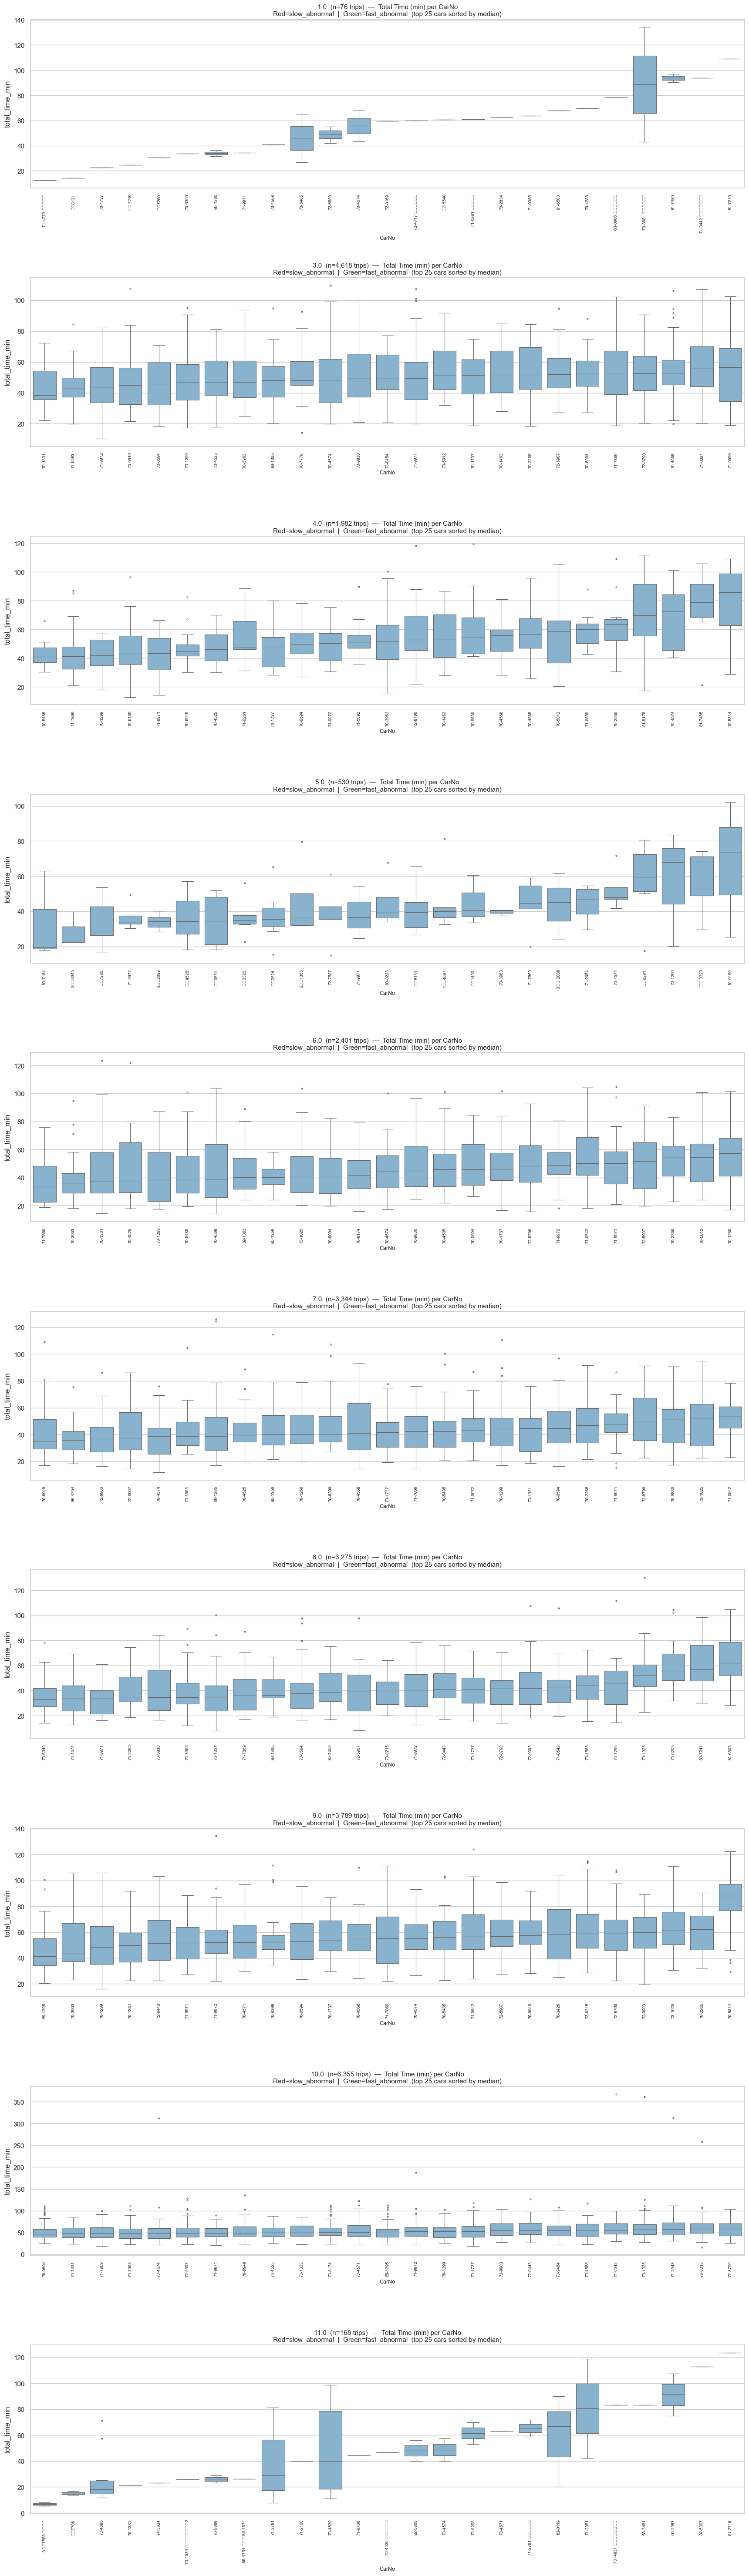

In [70]:
if place_col is not None and 'CarNo' in analysis_df.columns:
    flag_palette = {
        'slow_abnormal': '#e74c3c',
        'fast_abnormal': '#27ae60',
        'normal':        '#7db5d8',
    }
    TOP_N = 25  # max cars per place

    fig, axes = plt.subplots(
        nrows=len(places), ncols=1,
        figsize=(18, 6 * len(places)),
        squeeze=False,
    )

    for i, place in enumerate(places):
        ax = axes[i, 0]
        place_data = analysis_df[analysis_df[place_col] == place].copy()

        top_cars = place_data['CarNo'].value_counts().head(TOP_N).index.tolist()
        plot_data = place_data[place_data['CarNo'].isin(top_cars)].copy()

        car_order = plot_data.groupby('CarNo')[total_col].median().sort_values().index.tolist()

        # map each car to its flag color (seaborn 0.13: use hue + palette dict)
        palette_dict = {
            car: flag_palette.get(truck_flag_map.get((place, car), 'normal'), '#7db5d8')
            for car in car_order
        }

        sns.boxplot(
            data=plot_data, x='CarNo', y=total_col,
            hue='CarNo', order=car_order, hue_order=car_order,
            palette=palette_dict, legend=False,
            fliersize=2, linewidth=0.8, ax=ax,
        )
        n_total = len(place_data)
        ax.set_title(
            f'{place}  (n={n_total:,} trips)  —  Total Time (min) per CarNo\n'
            f'Red=slow_abnormal  |  Green=fast_abnormal  (top {TOP_N} cars sorted by median)',
            fontsize=11,
        )
        ax.set_xlabel('CarNo', fontsize=9)
        ax.set_ylabel('total_time_min')
        ax.tick_params(axis='x', rotation=90, labelsize=7)

    plt.tight_layout(pad=3)
    plt.show()


## Remove Outliers — Domain Threshold (Level 1 + Level 2)

ใช้ **Domain Threshold** แบบ 2 ระดับ ปรับใหม่สำหรับข้อมูล 2025+ ที่ระบบ stable แล้ว

**Level 1A — Phase thresholds (domain rules)**

| Column | Upper cut (> X) | P99 จริง (2025+) | หมายเหตุ |
|---|:---:|:---:|---|
| `wait_call_min` | 50 min | 44.0 min | ไม่มี lower bound — <1 min เป็นไปได้ |
| `prepare_loading_min` | 50 min | 46.4 min | ยกเลิก lower bound — PrepareForward รถเข้าช่องทันทีได้ |
| `close_job_min` | 65 min | 58.9 min | >65 ผิดปกติชัดเจน |

**Level 1B — loading_time_min threshold by CarType (ปรับตาม P99 จริง)**

| CarType | Threshold | P99 (2025+) |
|---|:---:|:---:|
| 4W  | > 65 min  | 45.7 min |
| 6W  | > 95 min  | 59.6 min |
| 10W | > 100 min | 70.0 min |
| Trailer | > 125 min | 96.1 min |

**Level 2 — Total time direct cut**

| Column | Upper cut (> X) | P99 จริง (2025+) | IQR upper |
|---|:---:|:---:|:---:|
| `total_time_min` | 130 min | 117.7 min | 127.2 min |

> **เหตุผลที่ปรับ:** Rule เดิมออกแบบมาสำหรับข้อมูลก่อน 2025 ที่ mean ~90–250 min
> ข้อมูล 2025+ มี distribution ที่ compact กว่ามาก (mean=60, std=25) จึงใช้ threshold ที่ tight ขึ้นตาม P99 จริง

In [71]:
# ── Level 1A: Phase domain thresholds ────────────────────────────────────────
# ไม่มี lower bound สำหรับทุก phase — prepare_loading < 1 min เป็น behavior จริง (PrepareForward)
DOMAIN_RULES = {
    'wait_call_min':       {'slow': 25.0},
    'prepare_loading_min': {'slow': 28.0},
    'close_job_min':       {'slow': 40.0},
}

breakdown_rows = []
domain_remove = pd.Series(False, index=analysis_df.index)

for col, rules in DOMAIN_RULES.items():
    if col not in analysis_df.columns:
        continue
    if rules.get('slow') is not None:
        slow_mask = analysis_df[col] > rules['slow']
        domain_remove |= slow_mask
        breakdown_rows.append({'rule': f'{col} > {rules["slow"]} min (slow)', 'rows': int(slow_mask.sum())})

# ── Level 1B: loading_time_min threshold by CarType (ปรับตาม P99 จริง 2025+) ─
# CarType encoding: 0=10W, 1=4W, 2=6W, 3=Trailer
LOADING_THRESHOLD_BY_CARTYPE = {
    0: 100,   # 10W    — P99=70.0 min
    1:  60,   # 4W     — P99=45.7 min
    2:  90,   # 6W     — P99=59.6 min
    3: 120,   # Trailer — P99=96.1 min
}

if 'loading_time_min' in analysis_df.columns and 'CarType' in analysis_df.columns:
    for ct, thresh in LOADING_THRESHOLD_BY_CARTYPE.items():
        mask = (analysis_df['CarType'] == ct) & (analysis_df['loading_time_min'] > thresh)
        domain_remove |= mask
        breakdown_rows.append({
            'rule': f'loading_time_min > {thresh} min (CarType={ct})',
            'rows': int(mask.sum()),
        })

# ── Level 1C: loading z-score fallback ───────────────────────────────────────
loading_flag_col = 'loading_time_min_speed_flag'
if loading_flag_col in analysis_df.columns:
    loading_slow = analysis_df[loading_flag_col] == 'slow_abnormal'
    domain_remove |= loading_slow
    breakdown_rows.append({'rule': 'loading_time_min z-score >= 3.5 (slow)', 'rows': int(loading_slow.sum())})

# ── Level 2: total_time_min direct cut ───────────────────────────────────────
# P99=117.7, IQR upper=127.2 → 130 min เป็น threshold ที่ครอบ extreme outlier เท่านั้น
TOTAL_TIME_MAX = 120.0
if 'total_time_min' in analysis_df.columns:
    total_slow = analysis_df['total_time_min'] > TOTAL_TIME_MAX
    domain_remove |= total_slow
    breakdown_rows.append({'rule': f'total_time_min > {TOTAL_TIME_MAX} min (Level 2)', 'rows': int(total_slow.sum())})

# ── Apply ─────────────────────────────────────────────────────────────────────
keep_mask = ~domain_remove
df_feature_clean = analysis_df.loc[keep_mask, df_feature.columns].copy()

# ── Report ────────────────────────────────────────────────────────────────────
print(f'Before : {len(analysis_df):,} rows')
print(f'After  : {len(df_feature_clean):,} rows')
print(f'Removed: {domain_remove.sum():,} rows ({domain_remove.mean()*100:.2f}%)')
print()

breakdown_df = pd.DataFrame(breakdown_rows)
breakdown_df['pct'] = (breakdown_df['rows'] / len(analysis_df) * 100).round(2)
display(breakdown_df)

print()
print('--- Clean data distribution ---')
check_cols = list(DOMAIN_RULES.keys()) + ['loading_time_min', 'total_time_min']
check_cols = [c for c in check_cols if c in df_feature_clean.columns]
display(df_feature_clean[check_cols]
        .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T
        .round(2))

Before : 26,538 rows
After  : 22,085 rows
Removed: 4,453 rows (16.78%)



,rule,rows,pct
0,wait_call_min > 25.0 min (slow),1600,6.03
1,prepare_loading_min > 28.0 min (slow),1497,5.64
2,close_job_min > 40.0 min (slow),1319,4.97
3,loading_time_min > 100 min (CarType=0),0,0.00
4,loading_time_min > 60 min (CarType=1),135,0.51
5,loading_time_min > 90 min (CarType=2),2,0.01
6,loading_time_min > 120 min (CarType=3),4,0.02
7,loading_time_min z-score >= 3.5 (slow),0,0.00
8,total_time_min > 120.0 min (Level 2),203,0.76



--- Clean data distribution ---


,count,mean,std,min,50%,75%,90%,95%,99%,max
wait_call_min,22085.0,7.28,5.56,0.05,5.57,10.28,15.75,19.13,23.40,24.98
prepare_loading_min,22085.0,7.18,6.67,0.10,4.92,10.72,17.68,21.58,26.32,27.98
close_job_min,22085.0,15.05,8.56,1.13,13.17,20.12,27.90,32.48,38.02,40.00
loading_time_min,22085.0,25.12,19.12,0.02,20.70,34.57,51.98,64.15,86.14,109.93
total_time_min,22085.0,54.63,21.57,5.43,51.78,67.83,85.09,96.32,111.52,120.00


## Save Outlier-Removed Data

In [72]:
source_path = Path(source_path) 

output_name = 'vw_timestamp_dashboard_featured_no_outlier.csv'      
output_path = source_path.with_name(output_name)

try:
    df_feature_clean.to_csv(output_path, index=False, encoding='utf-8-sig')
    saved_path = output_path
except PermissionError:
    saved_path = output_path.with_name(f'{output_path.stem}_latest.csv')
    df_feature_clean.to_csv(saved_path, index=False, encoding='utf-8-sig')
    print('Could not overwrite target file; saved fallback file instead.')

print(f'Saved to: {saved_path}')
print(f'Shape  : {df_feature_clean.shape}')

Saved to: ..\..\data\interim\vw_timestamp_dashboard_featured_no_outlier.csv
Shape  : (22085, 68)
